In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score

In [13]:

# Импорт только табличного AutoML
from autogluon.tabular import TabularPredictor

# ===================== 1. Загрузка данных и выбор признаков/метки =====================
df = pd.read_csv("lab2_data.csv")

features = ['Count_subj', 'rr_interval', 'p_end', 'qrs_onset', 'qrs_end',
            'p_axis', 'qrs_axis', 't_axis']
target = 'Healthy_Status'

data = df[features + [target]].dropna()
X = data[features]
y = data[target]

In [15]:

# ===================== 2. Предварительная обработка данных =====================
print("Выполняется предварительная обработка данных...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Подготовка DataFrame для AutoGluon
train_data = pd.DataFrame(X_train, columns=features)
train_data[target] = y_train.values
test_data = pd.DataFrame(X_test, columns=features)
# Тестовые данные не содержат целевую переменную при предсказании, но для оценки она у нас есть

Выполняется предварительная обработка данных...


Выполняется снижение размерности с помощью PCA...


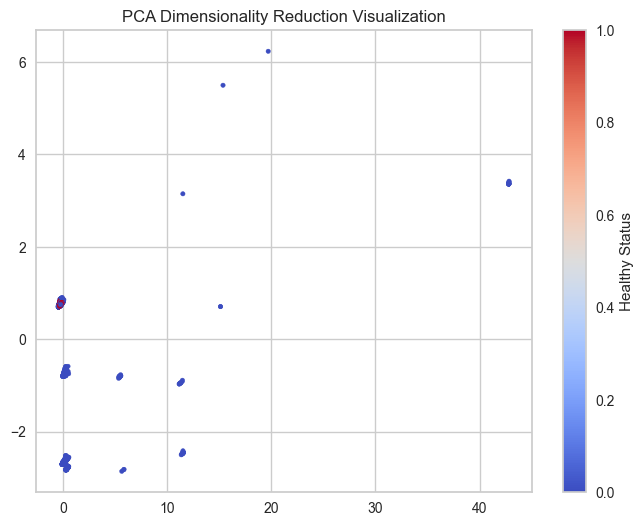

In [16]:

# ===================== 3. PCA визуализация =====================
print("Выполняется снижение размерности с помощью PCA...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', s=10)
plt.title("PCA Dimensionality Reduction Visualization")
plt.colorbar(scatter, label='Healthy Status')
plt.show()

Выполняется снижение размерности с помощью t-SNE...


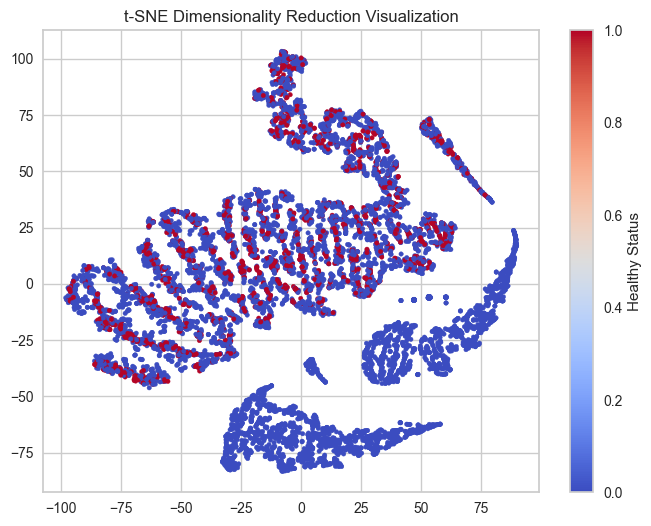

In [17]:

# ===================== 4. t-SNE визуализация =====================
print("Выполняется снижение размерности с помощью t-SNE...")
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='coolwarm', s=10)
plt.title("t-SNE Dimensionality Reduction Visualization")
plt.colorbar(scatter, label='Healthy Status')
plt.show()

No path specified. Models will be saved in: "AutogluonModels\ag-20260424_093421"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.1.1
Python Version:     3.8.0
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          32
Memory Avail:       4.78 GB / 13.70 GB (34.9%)
Disk Space Avail:   431.59 GB / 822.42 GB (52.5%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets.
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='best_quality'   : Maximize accuracy. Default time_limit=3600.
	presets='high_quality'   : Strong accuracy with fast inference speed. Default time_limit=3600.
	presets='good_quality'   : Good accuracy with very fast inference speed. Default time_limit=3600.
	presets='medium_quality' : Fast training time, ideal for initial prot


Автоматическое обучение с помощью AutoML (AutoGluon Tabular)...


	0.6341	 = Validation score   (f1)
	1.51s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: LightGBM ... Training model for up to 58.3s of the 58.3s of remaining time.
	0.678	 = Validation score   (f1)
	0.9s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ... Training model for up to 57.38s of the 57.37s of remaining time.
	0.5981	 = Validation score   (f1)
	0.46s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: RandomForestEntr ... Training model for up to 56.85s of the 56.84s of remaining time.
	0.6177	 = Validation score   (f1)
	0.46s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: CatBoost ... Training model for up to 56.3s of the 56.3s of remaining time.
		
Fitting model: ExtraTreesGini ... Training model for up to 56.23s of the 56.23s of remaining time.
	0.5233	 = Validation score   (f1)
	0.43s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: ExtraTreesEntr ... Training model fo


🏆 Оптимальная модель (выбрана AutoML): WeightedEnsemble_L2
🎯 Точность классификатора: 0.8480
🎯 Оценка F1: 0.6465


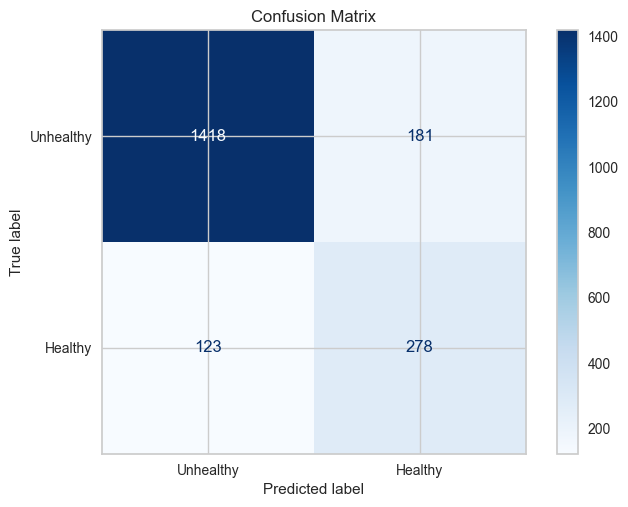

In [18]:

# ===================== 5. AutoML (AutoGluon Tabular) =====================
print("\n" + "=" * 60)
print("Автоматическое обучение с помощью AutoML (AutoGluon Tabular)...")
print("=" * 60)

# Создание и обучение AutoML модели
predictor = TabularPredictor(label=target, problem_type='binary', eval_metric='f1')
predictor.fit(train_data, time_limit=60, verbosity=2)

# Вывод лучшей модели
best_model_name = predictor.model_best
print(f"\n🏆 Оптимальная модель (выбрана AutoML): {best_model_name}")

# Предсказание на тестовой выборке
y_pred = predictor.predict(test_data)

# Оценка
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"🎯 Точность классификатора: {accuracy:.4f}")
print(f"🎯 Оценка F1: {f1:.4f}")
print("=" * 60)

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Unhealthy', 'Healthy']).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

Выполняется предварительная обработка данных...
Выполняется снижение размерности с помощью PCA...


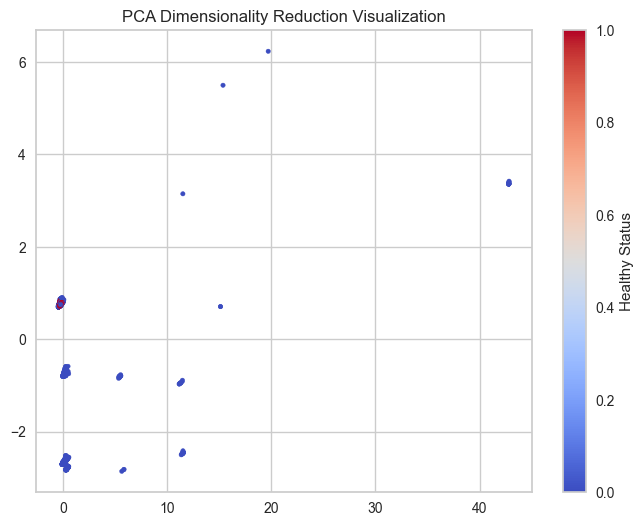

Выполняется снижение размерности с помощью t-SNE...


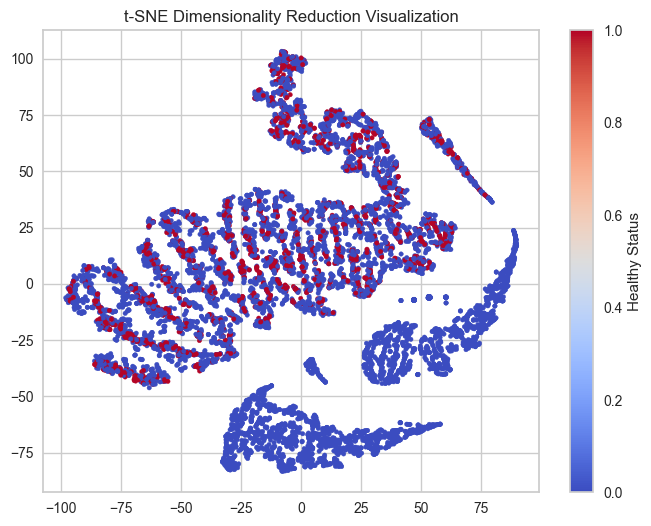

No path specified. Models will be saved in: "AutogluonModels\ag-20260424_092016"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.1.1
Python Version:     3.8.0
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          32
Memory Avail:       4.86 GB / 13.70 GB (35.5%)
Disk Space Avail:   431.49 GB / 822.42 GB (52.5%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets.
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='best_quality'   : Maximize accuracy. Default time_limit=3600.
	presets='high_quality'   : Strong accuracy with fast inference speed. Default time_limit=3600.
	presets='good_quality'   : Good accuracy with very fast inference speed. Default time_limit=3600.
	presets='medium_quality' : Fast training time, ideal for initial prot


Автоматическое обучение с помощью AutoML (AutoGluon Tabular)...


	0.4	 = Validation score   (f1)
	0.01s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: LightGBMXT ... Training model for up to 59.82s of the 59.82s of remaining time.
	0.6341	 = Validation score   (f1)
	1.64s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: LightGBM ... Training model for up to 58.13s of the 58.13s of remaining time.
	0.678	 = Validation score   (f1)
	0.81s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: RandomForestGini ... Training model for up to 57.3s of the 57.29s of remaining time.
	0.5981	 = Validation score   (f1)
	0.49s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: RandomForestEntr ... Training model for up to 56.72s of the 56.72s of remaining time.
	0.6177	 = Validation score   (f1)
	0.49s	 = Training   runtime
	0.06s	 = Validation runtime
Fitting model: CatBoost ... Training model for up to 56.13s of the 56.13s of remaining time.
		
Fitting model: ExtraTreesGini ... Training model for u


🏆 Оптимальная модель (выбрана AutoML): WeightedEnsemble_L2
🎯 Точность классификатора: 0.8480
🎯 Оценка F1: 0.6465


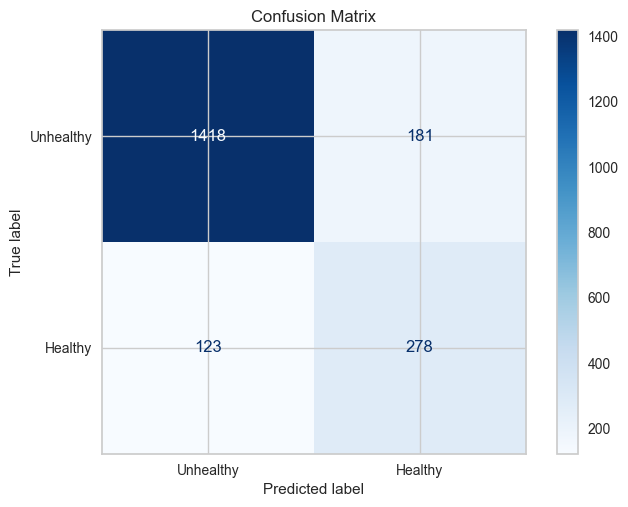

Модель не предоставляет важность признаков.


In [11]:

# ===================== 6. (Опционально) Важность признаков =====================
# Для лучшей модели (если поддерживается)
try:
    leader_model = predictor._trainer.load_model(predictor.model_best)
    if hasattr(leader_model, 'feature_importances_'):
        importances = leader_model.feature_importances_
        feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)
        feat_imp.plot(kind='bar', title="Feature Importance")
        plt.tight_layout()
        plt.show()
    else:
        print("Модель не предоставляет важность признаков.")
except Exception as e:
    print(f"Не удалось отобразить важность признаков: {e}")